# EDA & Data Understanding — NLBSE’23 Code Comment Classification (Python)

Notebook này tập trung vào phần **Dataset Understanding, EDA và tìm insight** để hỗ trợ các bước preprocessing, cross-validation, modeling và result analysis về sau. Notebook không huấn luyện mô hình.

Mục tiêu:

- xác minh nguồn, schema và cách mã hóa bài toán multi-label;
- kiểm tra missing, duplicate, tính nhất quán và nguy cơ data leakage;
- phân tích imbalance, label cardinality, label co-occurrence và train/test drift;
- khám phá độ dài, cấu trúc text, token, class và các tổ hợp nhãn;
- chuyển kết quả EDA thành quyết định cụ thể cho preprocessing, split, metric và baseline.

File đầu vào là **`data/python.csv`** trong repository.

## 0. Nguồn dữ liệu và phạm vi

<!-- EDA_V2_ADDITION -->

- Trang cuộc thi: [NLBSE’23 Tool Competition](https://nlbse2023.github.io/tools/)
- Repository chính thức: [nlbse2023/code-comment-classification](https://github.com/nlbse2023/code-comment-classification)
- Bài toán chính thức: xây dựng **một tập binary classifiers**, mỗi classifier xác định một câu thuộc hay không thuộc một category; một câu có thể thuộc nhiều category.
- NLBSE’23 công bố 6.738 câu trên toàn bộ bộ dữ liệu code-comment. Notebook này chỉ phân tích **subset Python** trong `python.csv`, vì vậy số câu phải được báo cáo theo file thực tế, không gán 6.738 cho riêng Python.
- Baseline chính thức của nhánh code-comment là Random Forest với TF-IDF/NLP features. Nếu dự án dùng RoBERTa/CodeBERT như baseline bổ sung, cần ghi rõ đó là thiết kế của nhóm và dùng cùng split/metric để so sánh công bằng.

### Cách đọc một dòng

Mỗi dòng là một cặp `(comment_sentence_id, category)`. `instance_type=1` nghĩa là câu thuộc category đó; `instance_type=0` nghĩa là không thuộc. Năm dòng của cùng một ID ghép lại thành một vector multi-label gồm 5 bit.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')

DATA_CANDIDATES = [Path('data/python.csv'), Path('../data/python.csv')]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), DATA_CANDIDATES[0])
assert DATA_PATH.exists(), f'Không tìm thấy file: {DATA_PATH}'
DATA_PATH

WindowsPath('data/python.csv')

## 1. Đọc dữ liệu, data dictionary và kiểm tra schema

| Cột | Ý nghĩa | Vai trò EDA |
|---|---|---|
| `comment_sentence_id` | ID duy nhất của câu | khóa để ghép 5 binary targets |
| `class` | tên class/source chứa comment | biến nhóm, hữu ích khi kiểm tra leakage |
| `comment_sentence` | nội dung câu comment | đầu vào text |
| `partition` | 0=train, 1=test cho classifier của category hiện tại | split chính thức theo từng binary task |
| `instance_type` | 0=negative, 1=positive | target nhị phân |
| `category` | category đang được xét | tên target |

Notebook kiểm tra schema trước khi phân tích để lỗi dữ liệu xuất hiện sớm và rõ ràng.

In [2]:
df = pd.read_csv(DATA_PATH)
required = {'comment_sentence_id', 'class', 'comment_sentence', 'partition', 'instance_type', 'category'}
missing_columns = required - set(df.columns)
assert not missing_columns, f'Thiếu cột: {missing_columns}'

print(f'Số dòng long-format : {len(df):,}')
print(f'Số câu/ID duy nhất   : {df.comment_sentence_id.nunique():,}')
print(f'Số class duy nhất    : {df["class"].nunique():,}')
print(f'Số category          : {df.category.nunique():,}')
display(df.head())
display(df.dtypes.to_frame('dtype').T)

Số dòng long-format : 12,775
Số câu/ID duy nhất   : 2,555
Số class duy nhất    : 330
Số category          : 5


,comment_sentence_id,class,comment_sentence,partition,instance_type,category
0,1,AccessMixin,abstract cbv mixin that gives access mixins the same customizable,0,0,Usage
1,2,AccessMixin,functionality.,1,0,Usage
2,5,AmbiguityError,more than one migration matches a name prefix.,0,0,Usage
3,7,AppConfigStub,stub of an appconfig.,1,0,Usage
4,8,AppConfigStub,only provides a label and a dict of models.,0,0,Usage


,comment_sentence_id,class,comment_sentence,partition,instance_type,category
dtype,int64,object,object,int64,int64,object


In [3]:
quality = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isna().sum(),
    'missing_%': (df.isna().mean() * 100).round(2),
    'n_unique': df.nunique(dropna=False),
})
display(quality)

print('Dòng trùng hoàn toàn:', df.duplicated().sum())
print('Giá trị instance_type:', sorted(df.instance_type.unique().tolist()))
print('Giá trị partition:', sorted(df.partition.unique().tolist()))
assert set(df.instance_type.unique()).issubset({0, 1}), 'instance_type không còn là biến nhị phân'
assert set(df.partition.unique()).issubset({0, 1}), 'partition có giá trị ngoài 0/1'

,dtype,missing,missing_%,n_unique
comment_sentence_id,int64,0,0.0,2555
class,object,0,0.0,330
comment_sentence,object,0,0.0,2299
partition,int64,0,0.0,2
instance_type,int64,0,0.0,2
category,object,0,0.0,5


Dòng trùng hoàn toàn: 0
Giá trị instance_type: [0, 1]
Giá trị partition: [0, 1]


,status
Đủ 6 cột bắt buộc,PASS
Không có missing,PASS
Không có dòng trùng hoàn toàn,PASS
instance_type chỉ gồm 0/1,PASS
partition chỉ gồm 0/1,PASS
Mỗi ID có đúng 1 text,PASS
Mỗi ID có đúng 1 class,PASS
Không có text rỗng,PASS


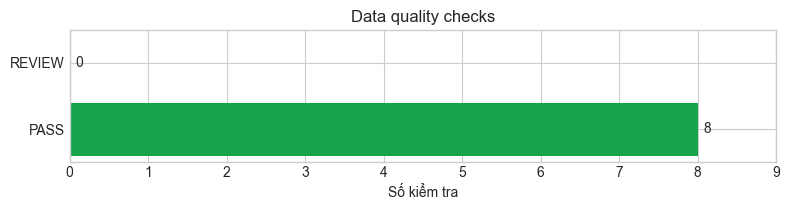

In [4]:
# EDA_V2_ADDITION — scorecard chất lượng và tính toàn vẹn
text_once = df.drop_duplicates('comment_sentence_id').copy()
integrity_checks = pd.Series({
    'Đủ 6 cột bắt buộc': required.issubset(df.columns),
    'Không có missing': not df.isna().any().any(),
    'Không có dòng trùng hoàn toàn': df.duplicated().sum() == 0,
    'instance_type chỉ gồm 0/1': set(df.instance_type.unique()).issubset({0, 1}),
    'partition chỉ gồm 0/1': set(df.partition.unique()).issubset({0, 1}),
    'Mỗi ID có đúng 1 text': df.groupby('comment_sentence_id').comment_sentence.nunique().eq(1).all(),
    'Mỗi ID có đúng 1 class': df.groupby('comment_sentence_id')['class'].nunique().eq(1).all(),
    'Không có text rỗng': text_once.comment_sentence.str.strip().ne('').all(),
}, name='passed').to_frame()
integrity_checks['status'] = integrity_checks.passed.map({True: 'PASS', False: 'REVIEW'})
display(integrity_checks[['status']])

fig, ax = plt.subplots(figsize=(8, 2.2))
counts = integrity_checks.status.value_counts().reindex(['PASS', 'REVIEW'], fill_value=0)
bars = ax.barh(counts.index, counts.values, color=['#16a34a', '#dc2626'])
ax.bar_label(bars, padding=4)
ax.set(title='Data quality checks', xlabel='Số kiểm tra', ylabel='')
ax.set_xlim(0, max(counts.max() + 1, 2))
plt.tight_layout()
plt.show()

## 2. Xác minh cách mã hóa multi-label

Một mẫu hợp lệ ở dạng long one-vs-rest phải có đúng một dòng cho mỗi `category`, đồng thời text và class không đổi trong cùng ID. Sau đó ta pivot `instance_type` thành các cột nhãn 0/1.

In [5]:
id_check = df.groupby('comment_sentence_id').agg(
    rows=('category', 'size'),
    n_categories=('category', 'nunique'),
    n_texts=('comment_sentence', 'nunique'),
    n_classes=('class', 'nunique'),
    n_partitions=('partition', 'nunique'),
)
display(id_check.describe().round(2))

expected_categories = df.category.nunique()
invalid_ids = id_check.query(
    'rows != @expected_categories or n_categories != @expected_categories or n_texts != 1 or n_classes != 1'
)
print(f'ID vi phạm cấu trúc long-format: {len(invalid_ids):,}')
assert invalid_ids.empty, 'Cần xử lý các ID không nhất quán trước khi pivot'

example_id = df.comment_sentence_id.iloc[0]
display(df.query('comment_sentence_id == @example_id').sort_values('category'))

,rows,n_categories,n_texts,n_classes,n_partitions
count,2555.0,2555.0,2555.0,2555.0,2555.00
mean,5.0,5.0,1.0,1.0,1.48
std,0.0,0.0,0.0,0.0,0.50
min,5.0,5.0,1.0,1.0,1.00
25%,5.0,5.0,1.0,1.0,1.00
50%,5.0,5.0,1.0,1.0,1.00
75%,5.0,5.0,1.0,1.0,2.00
max,5.0,5.0,1.0,1.0,2.00


ID vi phạm cấu trúc long-format: 0


,comment_sentence_id,class,comment_sentence,partition,instance_type,category
3517,1,AccessMixin,abstract cbv mixin that gives access mixins the same customizable,1,0,DevelopmentNotes
5760,1,AccessMixin,abstract cbv mixin that gives access mixins the same customizable,1,0,Expand
1756,1,AccessMixin,abstract cbv mixin that gives access mixins the same customizable,1,0,Parameters
12322,1,AccessMixin,abstract cbv mixin that gives access mixins the same customizable,1,1,Summary
0,1,AccessMixin,abstract cbv mixin that gives access mixins the same customizable,0,0,Usage


In [6]:
meta = (
    df[['comment_sentence_id', 'class', 'comment_sentence']]
    .drop_duplicates('comment_sentence_id')
    .set_index('comment_sentence_id')
)
y = (
    df.pivot(index='comment_sentence_id', columns='category', values='instance_type')
    .astype('int8')
    .sort_index(axis=1)
)
wide = meta.join(y).reset_index()
label_cols = y.columns.tolist()

print('Kích thước dữ liệu wide:', wide.shape)
print('Các nhãn:', label_cols)
display(wide.head())

Kích thước dữ liệu wide: (2555, 8)
Các nhãn: ['DevelopmentNotes', 'Expand', 'Parameters', 'Summary', 'Usage']


,comment_sentence_id,class,comment_sentence,DevelopmentNotes,Expand,Parameters,Summary,Usage
0,1,AccessMixin,abstract cbv mixin that gives access mixins the same customizable,0,0,0,1,0
1,2,AccessMixin,functionality.,0,0,0,1,0
2,5,AmbiguityError,more than one migration matches a name prefix.,0,0,0,1,0
3,7,AppConfigStub,stub of an appconfig.,0,0,0,1,0
4,8,AppConfigStub,only provides a label and a dict of models.,0,0,1,0,0


## 3. Phân bố nhãn và mức mất cân bằng

- **Prevalence**: tỷ lệ mẫu dương của từng nhãn.
- **Imbalance ratio**: số âm / số dương; càng lớn càng khó học nhãn thiểu số.
- Không nên đánh giá chỉ bằng accuracy vì phần lớn ô trong ma trận nhãn là 0.

,positive,negative,prevalence_%,neg/pos_ratio
category,,,,
Usage,800,1755,31.31,2.19
Parameters,794,1761,31.08,2.22
Expand,504,2051,19.73,4.07
Summary,454,2101,17.77,4.63
DevelopmentNotes,312,2243,12.21,7.19


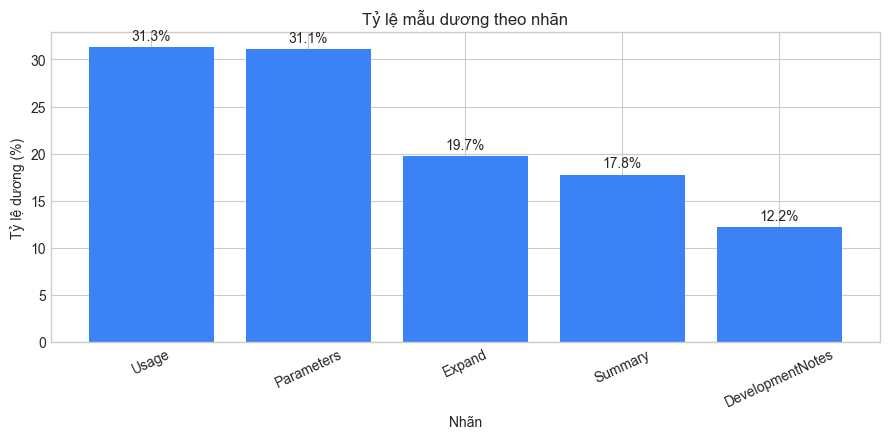

In [7]:
label_stats = pd.DataFrame({
    'positive': y.sum(),
    'negative': len(y) - y.sum(),
    'prevalence_%': (100 * y.mean()).round(2),
})
label_stats['neg/pos_ratio'] = (label_stats.negative / label_stats.positive).round(2)
label_stats = label_stats.sort_values('positive', ascending=False)
display(label_stats)

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(label_stats.index, label_stats['prevalence_%'], color='#3b82f6')
ax.set(title='Tỷ lệ mẫu dương theo nhãn', xlabel='Nhãn', ylabel='Tỷ lệ dương (%)')
ax.tick_params(axis='x', rotation=25)
ax.bar_label(bars, fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.show()

Label cardinality (nhãn dương/mẫu): 1.121
Label density: 0.224
Mẫu không có nhãn dương: 0


,samples
1,2271
2,259
3,25


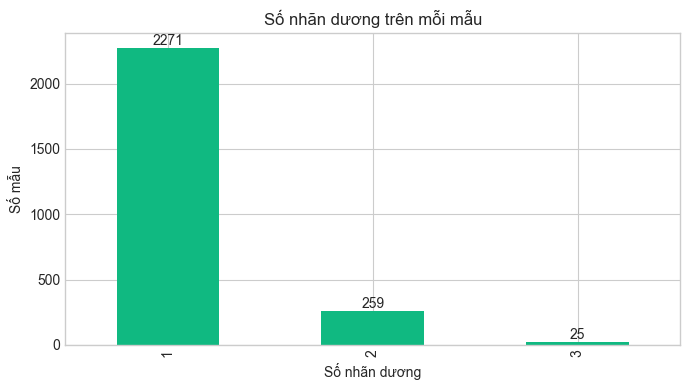

In [8]:
label_count = y.sum(axis=1)
cardinality = label_count.mean()
density = cardinality / y.shape[1]

print(f'Label cardinality (nhãn dương/mẫu): {cardinality:.3f}')
print(f'Label density: {density:.3f}')
print(f'Mẫu không có nhãn dương: {(label_count == 0).sum():,}')
display(label_count.value_counts().sort_index().rename('samples').to_frame())

ax = label_count.value_counts().sort_index().plot.bar(figsize=(7, 4), color='#10b981')
ax.set(title='Số nhãn dương trên mỗi mẫu', xlabel='Số nhãn dương', ylabel='Số mẫu')
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

## 4. Đồng xuất hiện và quan hệ giữa các nhãn

Heatmap đầu tiên là số mẫu cùng dương. Jaccard chuẩn hóa theo kích thước hợp của hai tập mẫu, giúp so sánh các cặp nhãn công bằng hơn.

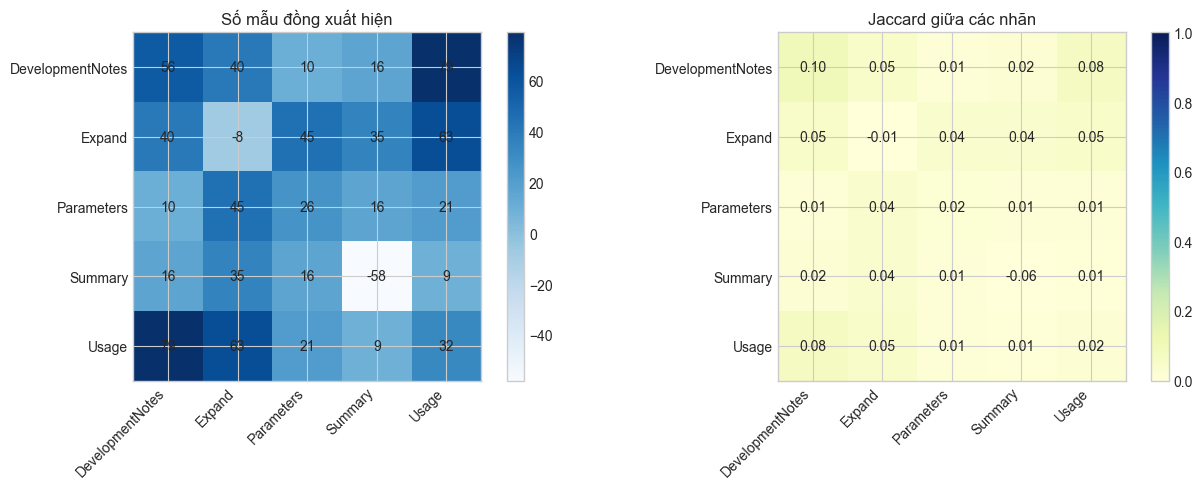

In [9]:
cooc = y.T.dot(y).astype(int)
union = np.zeros_like(cooc, dtype=float)
for i in range(len(label_cols)):
    for j in range(len(label_cols)):
        union[i, j] = y.iloc[:, i].sum() + y.iloc[:, j].sum() - cooc.iloc[i, j]
jaccard = cooc.to_numpy() / np.where(union == 0, 1, union)
jaccard = pd.DataFrame(jaccard, index=label_cols, columns=label_cols)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
im0 = axes[0].imshow(cooc, cmap='Blues')
axes[0].set_xticks(range(len(label_cols)), label_cols, rotation=45, ha='right')
axes[0].set_yticks(range(len(label_cols)), label_cols)
for i in range(len(label_cols)):
    for j in range(len(label_cols)):
        axes[0].text(j, i, f'{cooc.iloc[i, j]:d}', ha='center', va='center')
fig.colorbar(im0, ax=axes[0], fraction=.046)
axes[0].set_title('Số mẫu đồng xuất hiện')
im1 = axes[1].imshow(jaccard, cmap='YlGnBu', vmin=0, vmax=1)
axes[1].set_xticks(range(len(label_cols)), label_cols, rotation=45, ha='right')
axes[1].set_yticks(range(len(label_cols)), label_cols)
for i in range(len(label_cols)):
    for j in range(len(label_cols)):
        axes[1].text(j, i, f'{jaccard.iloc[i, j]:.2f}', ha='center', va='center')
fig.colorbar(im1, ax=axes[1], fraction=.046)
axes[1].set_title('Jaccard giữa các nhãn')
plt.tight_layout()
plt.show()

## 5. Phân tích văn bản

Độ dài theo từ và ký tự giúp lựa chọn `max_length` cho Transformer. Ta dùng phân vị thay vì lấy max tuyệt đối để tránh padding lãng phí do ngoại lệ.

,char_len,word_len
count,2555.00,2555.00
mean,38.70,6.73
std,22.51,4.04
min,1.00,0.00
50%,37.00,6.00
75%,59.00,10.00
90%,68.00,12.00
95%,72.30,13.00
99%,87.00,16.00
max,103.00,20.00


Có dấu hiệu code token: 39.2%
Bắt đầu bằng chữ thường: 96.2%


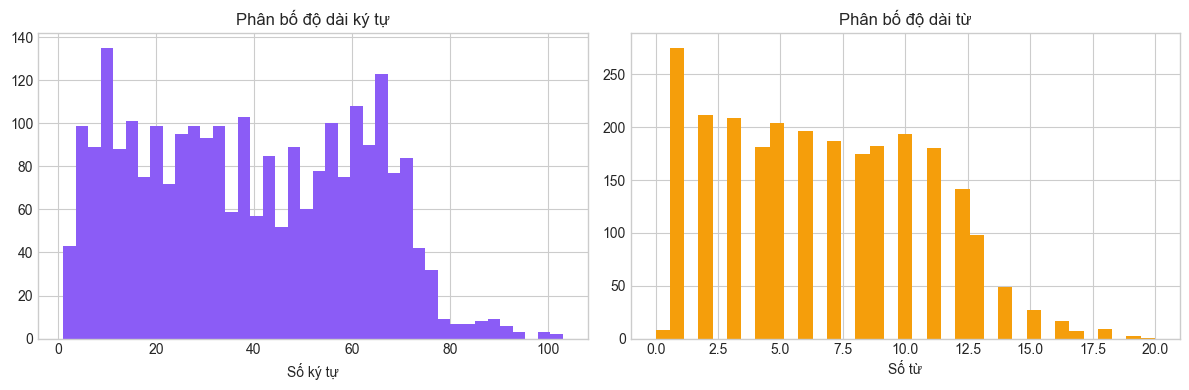

In [10]:
text_df = wide[['comment_sentence_id', 'class', 'comment_sentence']].copy()
text_df['char_len'] = text_df.comment_sentence.str.len()
text_df['word_len'] = text_df.comment_sentence.str.findall(r'\b\w+\b').str.len()
text_df['has_code_token'] = text_df.comment_sentence.str.contains(
    r'[_().=]|\b(?:class|def|return|None|True|False)\b', regex=True
)
text_df['starts_lowercase'] = text_df.comment_sentence.str.match(r'^[a-z]')

display(text_df[['char_len', 'word_len']].describe(percentiles=[.5, .75, .9, .95, .99]).round(2))
print(f'Có dấu hiệu code token: {text_df.has_code_token.mean():.1%}')
print(f'Bắt đầu bằng chữ thường: {text_df.starts_lowercase.mean():.1%}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(text_df.char_len, bins=40, color='#8b5cf6')
axes[0].set(title='Phân bố độ dài ký tự', xlabel='Số ký tự')
axes[1].hist(text_df.word_len, bins=35, color='#f59e0b')
axes[1].set(title='Phân bố độ dài từ', xlabel='Số từ')
plt.tight_layout()
plt.show()

,count,percent
empty_or_whitespace,0,0.00
one_word_or_less,283,11.08
three_words_or_less,704,27.55
all_lowercase,2548,99.73
ends_with_punctuation,909,35.58
contains_url,0,0.00
contains_email,0,0.00


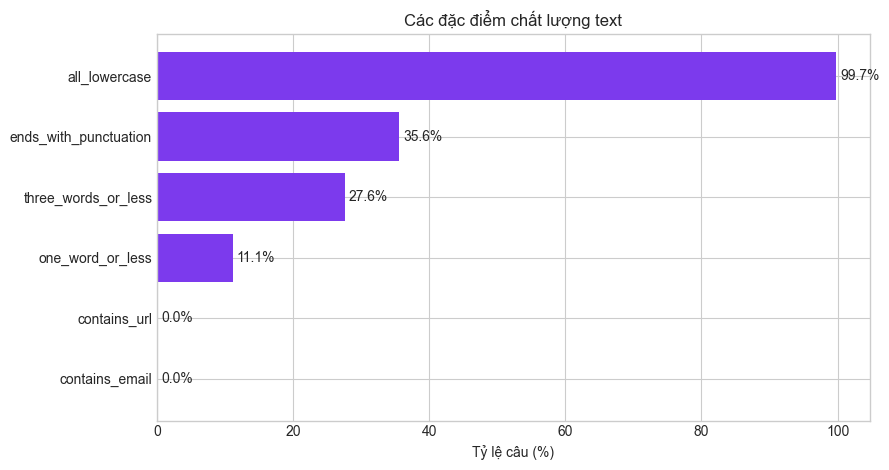

In [11]:
# EDA_V2_ADDITION — audit chất lượng text và mức preprocessing đã có
text_audit_stats = pd.Series({
    'empty_or_whitespace': text_df.comment_sentence.str.strip().eq('').sum(),
    'one_word_or_less': text_df.word_len.le(1).sum(),
    'three_words_or_less': text_df.word_len.le(3).sum(),
    'all_lowercase': text_df.comment_sentence.eq(text_df.comment_sentence.str.lower()).sum(),
    'ends_with_punctuation': text_df.comment_sentence.str.contains(r'[.!?]$').sum(),
    'contains_url': text_df.comment_sentence.str.contains(r'https?://|www\.', case=False, regex=True).sum(),
    'contains_email': text_df.comment_sentence.str.contains(r'\b[\w.+-]+@[\w.-]+\.[A-Za-z]{2,}\b', regex=True).sum(),
}, name='count').to_frame()
text_audit_stats['percent'] = (100 * text_audit_stats['count'] / len(text_df)).round(2)
display(text_audit_stats)

plot_stats = text_audit_stats.drop(index='empty_or_whitespace').sort_values('percent')
fig, ax = plt.subplots(figsize=(9, 4.8))
bars = ax.barh(plot_stats.index, plot_stats.percent, color='#7c3aed')
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set(title='Các đặc điểm chất lượng text', xlabel='Tỷ lệ câu (%)', ylabel='')
plt.tight_layout()
plt.show()

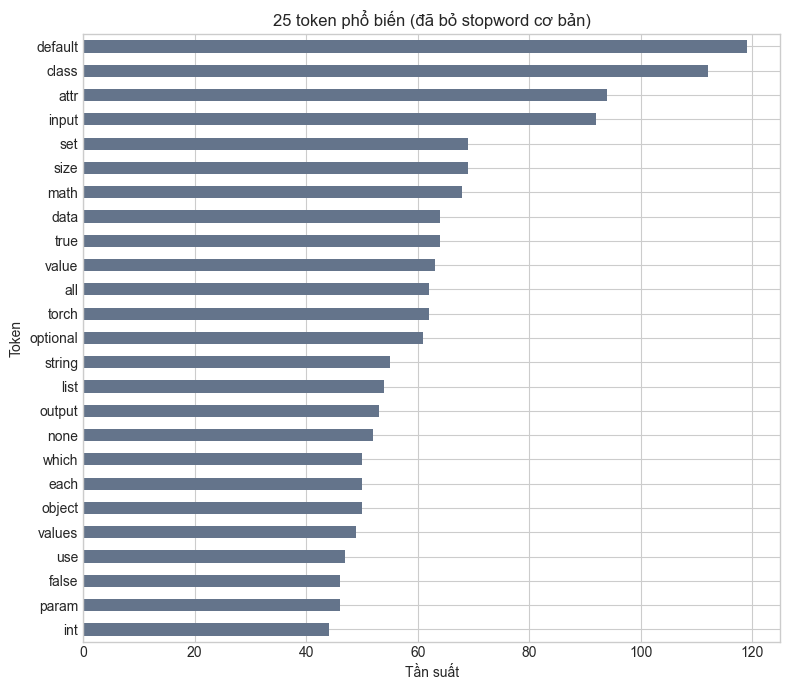

comment_sentence,default,class,attr,input,set,size,math,true,data,value,all,torch,optional,string,list,output,none,which,each,object,values,use,param,false,int
count,119,112,94,92,69,69,68,64,64,63,62,62,61,55,54,53,52,50,50,50,49,47,46,46,44


In [12]:
# Các token phổ biến sau tiền xử lý rất nhẹ; giữ nguyên tinh thần code comment.
stopwords = {
    'a','an','the','and','or','of','to','in','for','is','are','be','this','that',
    'with','as','on','by','from','it','if','not','will','can','used','using'
}
tokens = (
    text_df.comment_sentence.str.lower()
    .str.findall(r'[a-zA-Z_][a-zA-Z_0-9]+')
    .explode()
)
top_tokens = tokens[~tokens.isin(stopwords)].value_counts().head(25)

ax = top_tokens.sort_values().plot.barh(figsize=(8, 7), color='#64748b')
ax.set(title='25 token phổ biến (đã bỏ stopword cơ bản)', xlabel='Tần suất', ylabel='Token')
plt.tight_layout()
plt.show()
display(top_tokens.rename('count').to_frame().T)

## 6. Class, duplicate và split/leakage

Theo thiết kế chính thức, `partition` được gán cho từng binary task `(sentence, category)`. Do đó một ID có thể ở train của category này nhưng ở test của category khác; đây **không phải lỗi** khi huấn luyện 5 binary classifiers độc lập.

Hai cách đánh giá cần phân biệt rõ:

- **Reproduce NLBSE’23:** với từng category, dùng chính `partition` của các dòng category đó.
- **Mô hình joint multi-label + k-fold:** pivot sang wide-format, rồi tạo một split thống nhất theo ID/text/class; không thể lấy một giá trị `partition` duy nhất từ long-format.

Text giống nhau dưới nhiều ID hoặc nhiều câu cùng `class` có thể làm kết quả quá lạc quan nếu bị chia qua các fold. Vì thế notebook đo cả exact/normalized duplicates và độ tập trung theo class.

Số class: 330
Median số câu/class: 2
Class chỉ có 1 câu: 145


,n_sentences
class,
PlotAccessor,108
Unfold,94
Environment,92
Retry,83
BCEWithLogitsLoss,79
EmbeddingBag,70
ConfigDict,68
Conv3d,66
Audio,64


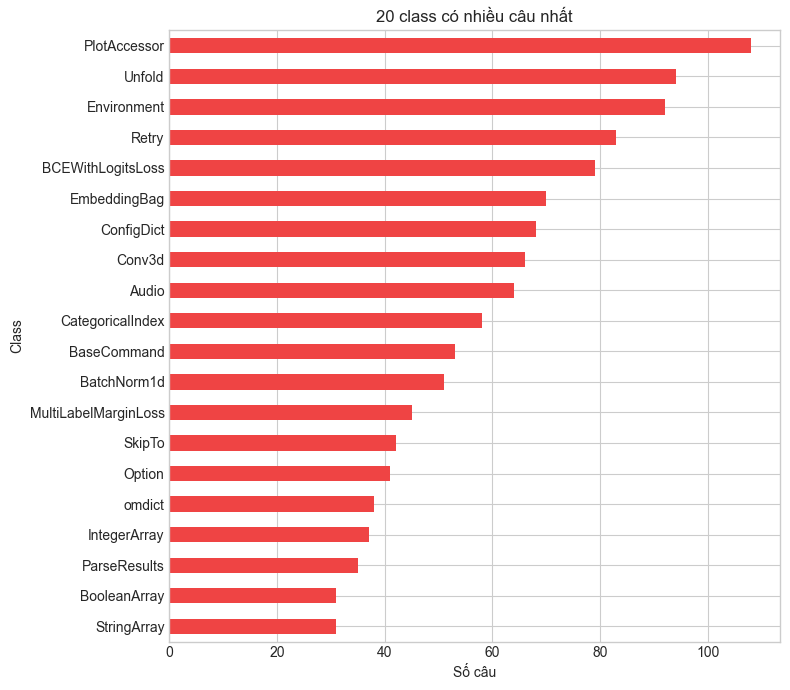

In [13]:
class_counts = text_df['class'].value_counts()
print(f'Số class: {class_counts.size:,}')
print(f'Median số câu/class: {class_counts.median():.0f}')
print(f'Class chỉ có 1 câu: {(class_counts == 1).sum():,}')
display(class_counts.head(15).rename('n_sentences').to_frame())

ax = class_counts.head(20).sort_values().plot.barh(figsize=(8, 7), color='#ef4444')
ax.set(title='20 class có nhiều câu nhất', xlabel='Số câu', ylabel='Class')
plt.tight_layout()
plt.show()

In [14]:
partition_by_id = df.groupby('comment_sentence_id').partition.nunique()
ids_with_category_specific_splits = int((partition_by_id > 1).sum())

normalized_text = (
    text_df.comment_sentence.str.lower()
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)
duplicate_text_rows = int(normalized_text.duplicated(keep=False).sum())
duplicate_text_groups = int(normalized_text[normalized_text.duplicated(keep=False)].nunique())

print(f'ID có partition khác nhau giữa các category: {ids_with_category_specific_splits:,}/{len(text_df):,}')
print('→ Hợp lệ với 5 binary classifiers; không dùng trực tiếp cho joint multi-label split.')
print(f'Mẫu thuộc nhóm normalized-text trùng: {duplicate_text_rows:,}')
print(f'Số nhóm normalized-text trùng: {duplicate_text_groups:,}')

partition_table = pd.crosstab(df.partition, df.category)
display(partition_table)

top10_class_share = class_counts.head(10).sum() / class_counts.sum()
print(f'Top 10 class chiếm {top10_class_share:.1%} số câu.')
print('Khuyến nghị: báo cáo rõ split protocol; group theo normalized text hoặc class khi mục tiêu là generalization.')

ID có partition khác nhau giữa các category: 1,231/2,555
→ Hợp lệ với 5 binary classifiers; không dùng trực tiếp cho joint multi-label split.
Mẫu thuộc nhóm normalized-text trùng: 368
Số nhóm normalized-text trùng: 112


category,DevelopmentNotes,Expand,Parameters,Summary,Usage
partition,,,,,
0,2039,2039,2037,2039,2038
1,516,516,518,516,517


Top 10 class chiếm 30.6% số câu.
Khuyến nghị: báo cáo rõ split protocol; group theo normalized text hoặc class khi mục tiêu là generalization.


,category,partition,n,positive,positive_rate,split
0,DevelopmentNotes,0,2039,247,12.11,Train
1,DevelopmentNotes,1,516,65,12.60,Test
2,Expand,0,2039,402,19.72,Train
3,Expand,1,516,102,19.77,Test
4,Parameters,0,2037,633,31.08,Train
5,Parameters,1,518,161,31.08,Test
6,Summary,0,2039,361,17.70,Train
7,Summary,1,516,93,18.02,Test
8,Usage,0,2038,637,31.26,Train
9,Usage,1,517,163,31.53,Test


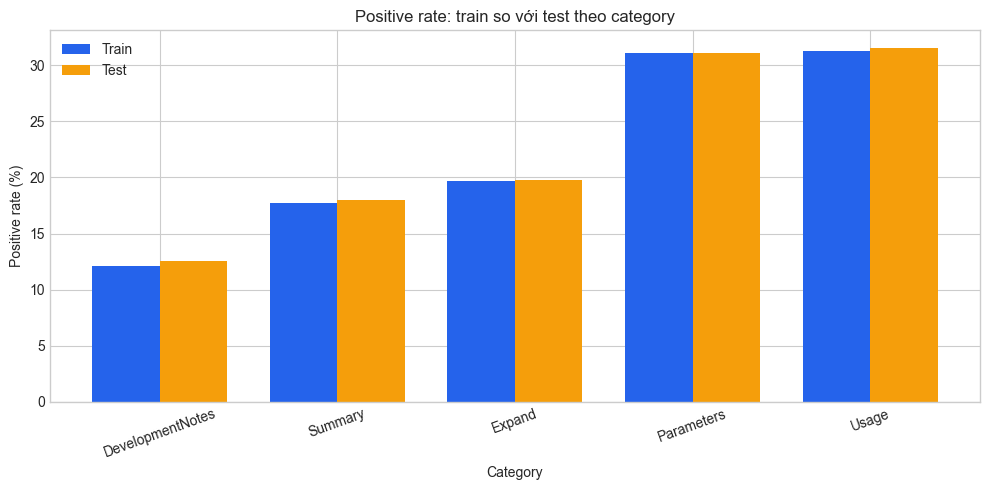

Chênh lệch positive-rate lớn nhất giữa train/test: 0.48 điểm % (DevelopmentNotes).


In [15]:
# EDA_V2_ADDITION — kiểm tra train/test drift theo từng binary task
split_stats = (
    df.groupby(['category', 'partition']).instance_type
    .agg(n='size', positive='sum', positive_rate='mean')
    .reset_index()
)
split_stats['split'] = split_stats.partition.map({0: 'Train', 1: 'Test'})
display(split_stats.assign(positive_rate=lambda x: (100 * x.positive_rate).round(2)))

rate_pivot = split_stats.pivot(index='category', columns='split', values='positive_rate') * 100
rate_pivot = rate_pivot.sort_values('Train')
x = np.arange(len(rate_pivot))
width = 0.38
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, rate_pivot['Train'], width, label='Train', color='#2563eb')
ax.bar(x + width/2, rate_pivot['Test'], width, label='Test', color='#f59e0b')
ax.set_xticks(x, rate_pivot.index, rotation=20)
ax.set(title='Positive rate: train so với test theo category', xlabel='Category', ylabel='Positive rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

rate_gap = (rate_pivot['Train'] - rate_pivot['Test']).abs()
print(f'Chênh lệch positive-rate lớn nhất giữa train/test: {rate_gap.max():.2f} điểm % ({rate_gap.idxmax()}).')

## 7. Dashboard trực quan EDA

Các biểu đồ dưới đây tổng hợp ba góc nhìn quan trọng nhất trước khi huấn luyện:

1. mức mất cân bằng dương/âm của từng nhãn;
2. các tổ hợp nhãn thường gặp trên cùng một comment;
3. sự khác biệt độ dài comment giữa các nhãn dương.

<!-- VISUAL_EDA_DASHBOARD -->

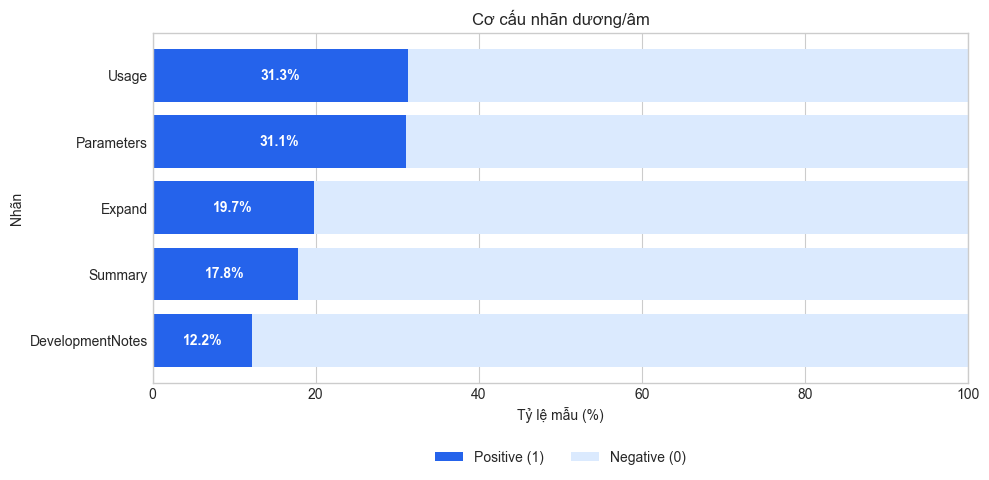

In [16]:
# VISUAL_EDA_DASHBOARD — tỷ lệ dương/âm theo từng nhãn
balance_pct = pd.DataFrame({
    'Positive': y.mean() * 100,
    'Negative': (1 - y.mean()) * 100,
}).sort_values('Positive')

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(balance_pct.index, balance_pct['Positive'], label='Positive (1)', color='#2563eb')
ax.barh(
    balance_pct.index,
    balance_pct['Negative'],
    left=balance_pct['Positive'],
    label='Negative (0)',
    color='#dbeafe',
)
for i, value in enumerate(balance_pct['Positive']):
    ax.text(value / 2, i, f'{value:.1f}%', ha='center', va='center', color='white', fontweight='bold')
ax.set(title='Cơ cấu nhãn dương/âm', xlabel='Tỷ lệ mẫu (%)', ylabel='Nhãn', xlim=(0, 100))
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.27), ncol=2)
plt.tight_layout()
plt.show()

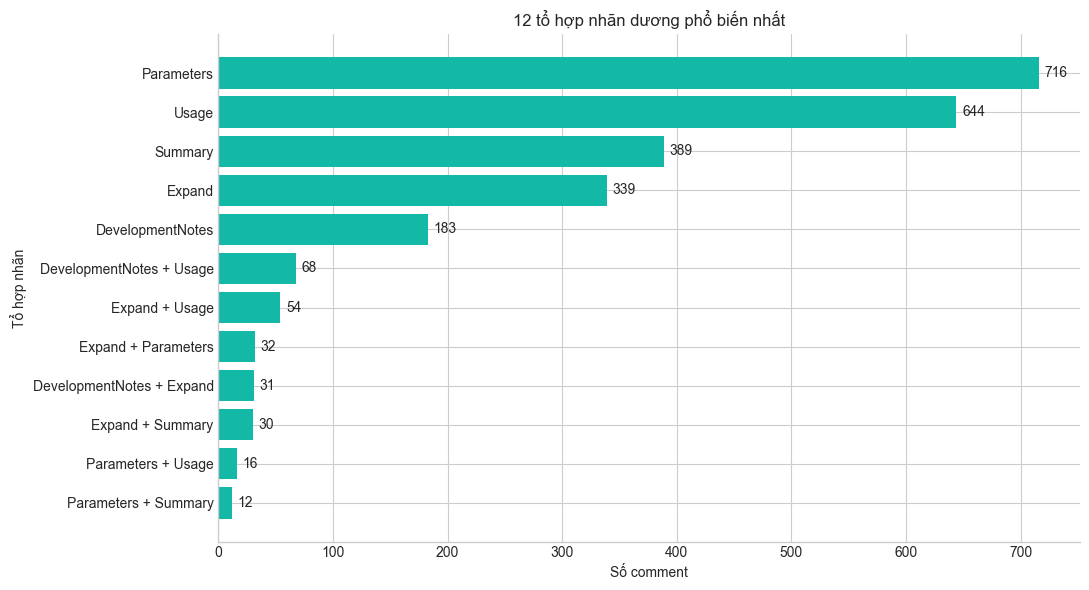

In [17]:
# VISUAL_EDA_DASHBOARD — các tổ hợp nhãn dương phổ biến
def label_combination(row):
    active = [label for label in label_cols if row[label] == 1]
    return ' + '.join(active) if active else '(không có nhãn)'

label_combinations = wide.apply(label_combination, axis=1).value_counts().head(12).sort_values()

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(label_combinations.index, label_combinations.values, color='#14b8a6')
ax.bar_label(bars, padding=4)
ax.set(
    title='12 tổ hợp nhãn dương phổ biến nhất',
    xlabel='Số comment',
    ylabel='Tổ hợp nhãn',
)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

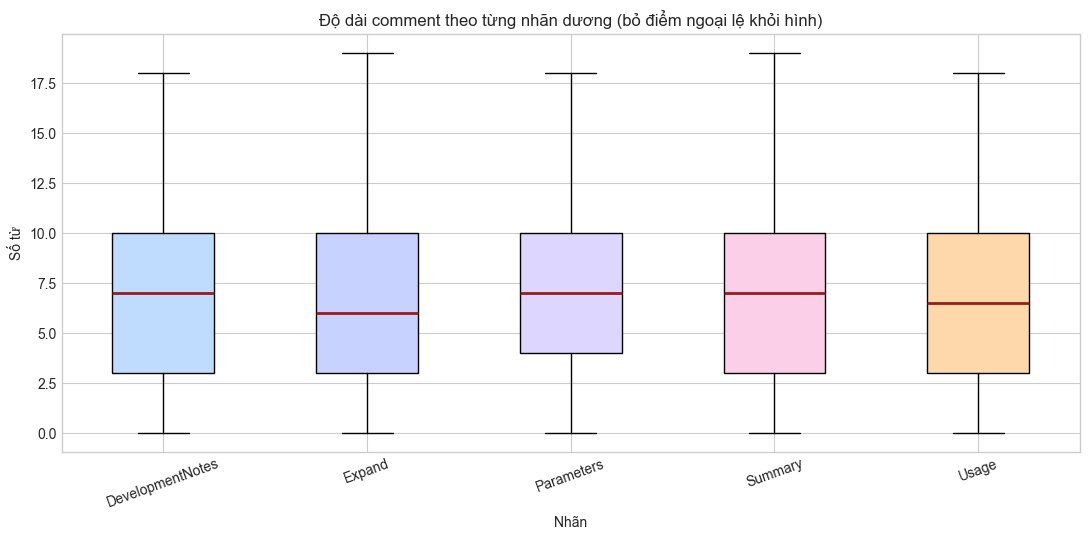

,count,mean,50%,75%,90%,max
DevelopmentNotes,312.0,6.88,7.0,10.0,12.0,18.0
Expand,504.0,6.47,6.0,10.0,12.0,19.0
Parameters,794.0,6.94,7.0,10.0,12.0,20.0
Summary,454.0,6.93,7.0,10.0,12.0,19.0
Usage,800.0,6.65,6.5,10.0,12.0,18.0


In [18]:
# VISUAL_EDA_DASHBOARD — độ dài comment theo nhãn dương
length_by_label = [
    text_df.loc[y[label].to_numpy().astype(bool), 'word_len'].to_numpy()
    for label in label_cols
]

fig, ax = plt.subplots(figsize=(11, 5.5))
box = ax.boxplot(
    length_by_label,
    tick_labels=label_cols,
    showfliers=False,
    patch_artist=True,
    medianprops={'color': '#991b1b', 'linewidth': 2},
)
colors = ['#bfdbfe', '#c7d2fe', '#ddd6fe', '#fbcfe8', '#fed7aa']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
ax.set(
    title='Độ dài comment theo từng nhãn dương (bỏ điểm ngoại lệ khỏi hình)',
    xlabel='Nhãn',
    ylabel='Số từ',
)
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

length_summary = pd.DataFrame({
    label: pd.Series(values).describe(percentiles=[.5, .75, .9])
    for label, values in zip(label_cols, length_by_label)
}).T[['count', 'mean', '50%', '75%', '90%', 'max']].round(2)
display(length_summary)

## 8. Insight EDA → quyết định cho pipeline

<!-- EDA_V2_ADDITION -->

| Quan sát từ EDA | Rủi ro | Quyết định đề xuất |
|---|---|---|
| Nhãn dương chỉ khoảng 12%–31% tùy category | accuracy gây hiểu nhầm | ưu tiên per-label F1, macro-F1, micro-F1, precision, recall và PR-AUC |
| Mỗi câu có 1–3 nhãn dương | softmax sai giả định | dùng 5 sigmoid outputs/BCE hoặc 5 binary classifiers |
| Train/test positive-rate gần nhau theo từng category | split chính thức đã cân bằng tốt | reproduce baseline bằng `partition` theo category |
| Cùng ID có thể có partition khác nhau giữa category | không có một split wide-format duy nhất | với joint model/k-fold, tạo split mới ở cấp ID/group và ghi rõ protocol |
| Có normalized-text duplicate | nguy cơ cùng nội dung ở cả train/test | group theo normalized text khi cross-validation |
| Nhiều câu ngắn/fragment và dữ liệu gần như đã lowercase | over-cleaning làm mất tín hiệu code | chỉ chuẩn hóa whitespace; giữ token code, dấu `_`, API names; fit TF-IDF trong fold |
| Phân bố class có long tail | model có thể nhớ class/API phổ biến | bổ sung GroupKFold theo `class` như robustness experiment |
| Comment nhìn chung ngắn | padding Transformer lãng phí | chọn `max_length` từ tokenizer percentile, không mặc định 512 |

### Artifact nên lưu để pipeline reproducible

- `data/processed/python_wide.parquet`: một dòng mỗi sentence, 5 cột target;
- `data/processed/label_map.json`: thứ tự label cố định;
- `artifacts/eda_summary.csv`: thống kê prevalence/cardinality/length;
- `artifacts/folds.csv`: mapping ID → fold, seed và split protocol;
- vectorizer/tokenizer và thresholds phải được lưu theo từng fold/model.

Trong development có thể cache `wide`, `y` trong memory; khi tái lập thí nghiệm phải đọc/ghi artifact có version trên file system và tuyệt đối không fit preprocessing trên test fold.

## 9. Cross-validation và metric đánh giá

### Hai protocol không được trộn lẫn

1. **Official hold-out reproduction:** lọc từng `category`, train ở `partition=0`, test ở `partition=1`; phù hợp để so với baseline NLBSE’23.
2. **5-fold model comparison:** dùng cùng folds cho mọi model. Với joint multi-label, ưu tiên iterative stratification và group theo normalized text; GroupKFold theo `class` là bài test generalization khó hơn.

Mọi bước TF-IDF, vocabulary, scaling, resampling, feature selection và threshold tuning phải fit **bên trong training fold**. Báo cáo mean ± std qua folds.

### Metric

- Theo từng category: Precision, Recall, F1 và PR-AUC của positive class.
- Tổng hợp: Micro-F1, Macro-F1 và mean per-label F1.
- Bổ sung cho joint multi-label: Hamming loss, Jaccard-samples, subset accuracy.
- Không dùng accuracy đơn lẻ do class imbalance.
- Threshold được tune trên validation fold, không tune trên test.

In [19]:
# Mẫu code tạo fold. Ưu tiên iterative stratification nếu đã cài package.
X = wide[['comment_sentence_id', 'class', 'comment_sentence']].copy()
Y = wide[label_cols].to_numpy()

try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
    splitter = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    folds = list(splitter.split(X, Y))
    split_method = 'MultilabelStratifiedKFold'
except ImportError:
    from sklearn.model_selection import KFold
    splitter = KFold(n_splits=5, shuffle=True, random_state=42)
    folds = list(splitter.split(X))
    split_method = 'KFold fallback (cài iterative-stratification để stratify multi-label)'

fold_rows = []
for fold, (train_idx, val_idx) in enumerate(folds, 1):
    row = {'fold': fold, 'train_n': len(train_idx), 'val_n': len(val_idx)}
    for j, label in enumerate(label_cols):
        row[f'{label}_val_%'] = round(100 * Y[val_idx, j].mean(), 2)
    fold_rows.append(row)

print('Phương pháp:', split_method)
display(pd.DataFrame(fold_rows))

Phương pháp: KFold fallback (cài iterative-stratification để stratify multi-label)


,fold,train_n,val_n,DevelopmentNotes_val_%,Expand_val_%,Parameters_val_%,Summary_val_%,Usage_val_%
0,1,2044,511,12.72,19.18,32.09,18.79,29.35
1,2,2044,511,14.29,20.74,30.14,18.20,31.51
2,3,2044,511,11.55,20.16,30.33,17.22,31.12
3,4,2044,511,10.18,18.98,31.31,17.61,32.49
4,5,2044,511,12.33,19.57,31.51,17.03,32.09


## 10. Hướng mô hình hóa và baseline so sánh

| Nhóm | Mô hình | Ghi chú |
|---|---|---|
| Dummy | dự đoán theo prevalence / nhãn phổ biến | mốc sàn bắt buộc |
| ML mạnh, rẻ | word + char TF-IDF → One-vs-Rest Logistic Regression | baseline nên chạy đầu tiên |
| Khai thác phụ thuộc nhãn | Classifier Chains / calibrated linear model | so với binary relevance |
| Transformer | RoBERTa + 5 sigmoid outputs + BCEWithLogitsLoss | baseline chuyên biệt theo đề bài |

Khuyến nghị cho RoBERTa:

- Không dùng softmax; đầu ra là 5 logits độc lập và loss là binary cross-entropy.
- Cân nhắc `pos_weight` theo nhãn hoặc focal loss, nhưng phải so sánh công bằng với BCE thường.
- Chọn `max_length` dựa trên phân vị độ dài token (file này có comment ngắn, không nên mặc định 512).
- Early stopping theo macro-F1 hoặc macro PR-AUC trên validation.
- Báo cáo metric tổng hợp, metric từng nhãn, thời gian train/inference và độ lệch chuẩn qua 5 fold.

Để so sánh đáng tin cậy, cùng một seed/fold, cùng quy tắc threshold, và không dùng test fold để chọn hyperparameter.

## 11. Kết luận tự động từ file hiện tại

In [20]:
rarest = label_stats['prevalence_%'].idxmin()
most_common = label_stats['prevalence_%'].idxmax()
p95_words = text_df.word_len.quantile(.95)

summary = f'''### Tóm tắt

- File có **{len(df):,} dòng long-format**, tương ứng **{len(wide):,} mẫu câu duy nhất**, **{len(label_cols)} nhãn** và **{text_df['class'].nunique():,} class**.
- Con số mẫu thực trong file (**{len(wide):,}**) không khớp mô tả 6.738 mẫu; cần xác nhận phiên bản/subset dữ liệu trước khi báo cáo cuối.
- Mỗi mẫu có trung bình **{cardinality:.2f} nhãn dương**; không có mẫu rỗng nhãn: **{int((label_count == 0).sum()):,}**.
- Nhãn phổ biến nhất là **{most_common}** ({label_stats.loc[most_common, 'prevalence_%']:.2f}%), hiếm nhất là **{rarest}** ({label_stats.loc[rarest, 'prevalence_%']:.2f}%).
- 95% câu có không quá **{p95_words:.0f} từ**, gợi ý sequence length ngắn là đủ cho phần lớn mẫu.
- Có **{ids_with_category_specific_splits:,} ID** nhận partition khác nhau giữa category: hợp lệ cho official binary setup, nhưng joint multi-label cần một split mới thống nhất.
- Có **{duplicate_text_rows:,} mẫu** nằm trong các nhóm text trùng; split cần group-aware để tránh leakage.
'''
display(Markdown(summary))

### Tóm tắt

- File có **12,775 dòng long-format**, tương ứng **2,555 mẫu câu duy nhất**, **5 nhãn** và **330 class**.
- Con số mẫu thực trong file (**2,555**) không khớp mô tả 6.738 mẫu; cần xác nhận phiên bản/subset dữ liệu trước khi báo cáo cuối.
- Mỗi mẫu có trung bình **1.12 nhãn dương**; không có mẫu rỗng nhãn: **0**.
- Nhãn phổ biến nhất là **Usage** (31.31%), hiếm nhất là **DevelopmentNotes** (12.21%).
- 95% câu có không quá **13 từ**, gợi ý sequence length ngắn là đủ cho phần lớn mẫu.
- Có **1,231 ID** nhận partition khác nhau giữa category: hợp lệ cho official binary setup, nhưng joint multi-label cần một split mới thống nhất.
- Có **368 mẫu** nằm trong các nhóm text trùng; split cần group-aware để tránh leakage.
